### **Importando as bibliotecas**

In [1]:
import lightkurve as  lk
import matplotlib.pyplot as plt 

%matplotlib inline

### **Informações sobre as bibliotecas**

### **1.1 Fotometria**

O termo fotometria surgiu com os oculistas, referindo-se à medida da quantidade de energia associada às sensações visuais. A fotometria é basicamente o estudo da quantidade de luz que chega até o observador. Hoje, usamos instrumentos muito mais sensíveis do que o olho humano para coletar esses dados, como câmeras digitais com CCDs (charge-coupled devices), que captam a luz de um objeto e a transformam em um sinal eletrônico que pode ser quantificado. Isso tudo, claro, em conjunto com um telescópio que foca e coleta a luz de um objeto distante [3].

Com isso, o que importa mais para nós neste momento é a curva de luz, que consiste no gráfico da variação do brilho do objeto — fluxo, medido em elétrons por segundo  $e^-s^{-1} $  — ao longo do tempo, que estará no sistema BTJD (Barycentric Julian Date).

### **1.2 TESS: Transiting Exoplanet Survey Satellite**


A missão TESS foi projetada para detectar planetas por trânsito, com a intenção de dar continuidade à onda de descobertas de exoplanetas do Kepler/K2. Desta vez, as estrelas mais próximas e mais brilhantes foram escolhidas como alvos, para que observações posteriores com telescópios terrestres e/ou outras missões espaciais possam estudar esses alvos mais a fundo.

As observações do TESS foram inicialmente divididas em setores (Figura 1) e, ao final de cada observação, o objeto se vira na direção leste, cerca de ~$27°$, para que a observação do próximo setor possa começar. Cada um desses processos leva cerca de 27 dias, sendo sincronizado com a órbita da Lua, o que nos permite observar 13 setores por ano. Com isso, a missão foi planejada para observar o hemisfério sul no primeiro ano e o hemisfério norte no segundo, resultando em 26 setores.


![setores.jpg](setores.jpg)

Figura 1 [5]: Repartição dos setores de observação da missão TESS. 

A partir das observações conduzidas pelo instrumento, recebemos dois tipos de dados como produto: com 2 minutos e com 30 minutos de exposição. O objeto que trataremos possui ambos os tipos, então usaremos os dois. Caso o leitor tenha interesse, mais detalhes técnicos sobre a missão podem ser encontrados no *TESS Instrument Handbook* [5].

Obs.: Algumas siglas importantes:
- *TOI*: TESS Objetc of Interest;
- *TIC*: TESS Input Catalog;
- *TICID*: Número de identificação de um objeto no catálogo.


In [26]:
TOI = 'TIC 376777782'
search_result = lk.search_lightcurve(TOI) 
# Como queremos trabalhar apenas com dados da missão TESS, restringimos a busca das curvas de luz.
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,376777782,0.0
1,TESS Sector 27,2020,SPOC,120,376777782,0.0
2,TESS Sector 67,2023,SPOC,120,376777782,0.0
3,TESS Sector 94,2025,SPOC,20,376777782,0.0
4,TESS Sector 94,2025,SPOC,120,376777782,0.0
5,TESS Sector 101,2026,SPOC,120,376777782,0.0
6,TESS Sector 13,2019,TESS-SPOC,1800,376777782,0.0
7,TESS Sector 27,2020,TESS-SPOC,600,376777782,0.0
8,TESS Sector 67,2023,TESS-SPOC,200,376777782,0.0


Observamos que há uma boa quantidade de dados disponíveis. Entretanto, estes são de autores diferentes e setores não seguidos. Se utilizarmos todas as curvas, o sinal resultante ficará deformado, não sendo interessante para a implementação do algoritmo. Então, para facilitar restringimos para os setores 16 ao 19, e com autores que estruturam os dados da mesma forma, como é o caso do TESS-SPOC e SPOC.

In [28]:
search_result = lk.search_lightcurve(TOI, mission = 'TESS', author = ['SPOC','TESS-SPOC'], sector =13)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,376777782,0.0
1,TESS Sector 13,2019,TESS-SPOC,1800,376777782,0.0


Com essa filtragem, agora estamos disponíveis a coletar os sinais para trabalhar. Utilizamos a função `download_all` para baixar as curvas em nosso computador e plotamos para vermos o que temos.

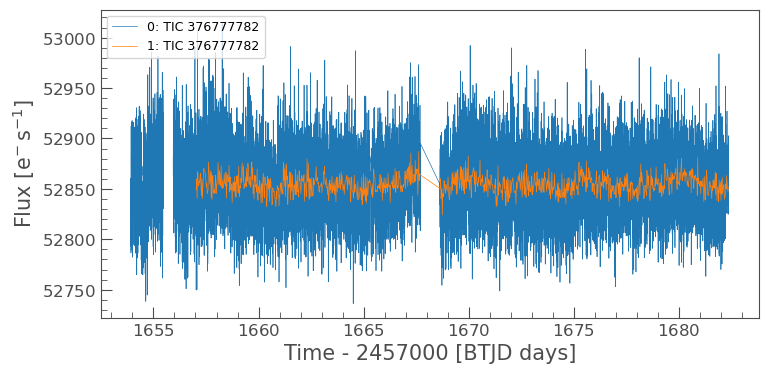

In [30]:
tess = search_result.download_all()
tess.plot()
plt.legend(fontsize="9", loc ="upper left")

Agora, normalizamos o fluxo e "costuramos" os dados para tirar as descontinuidades usando o `stitch`. Em seguida, removemos os outliers (pontos que divergem muito dos demais na série temporal).

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

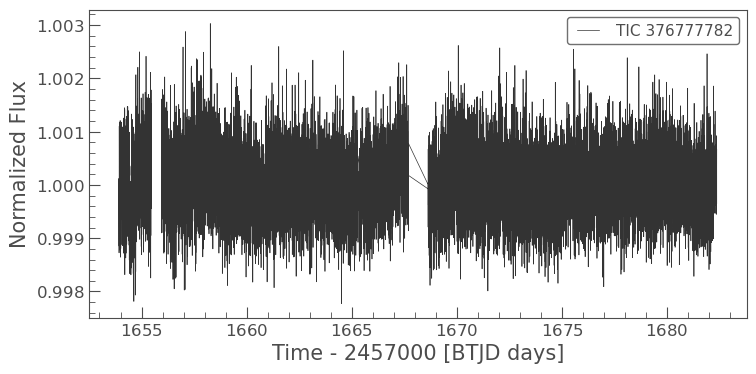

In [31]:
tess = tess.stitch() 
tess.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

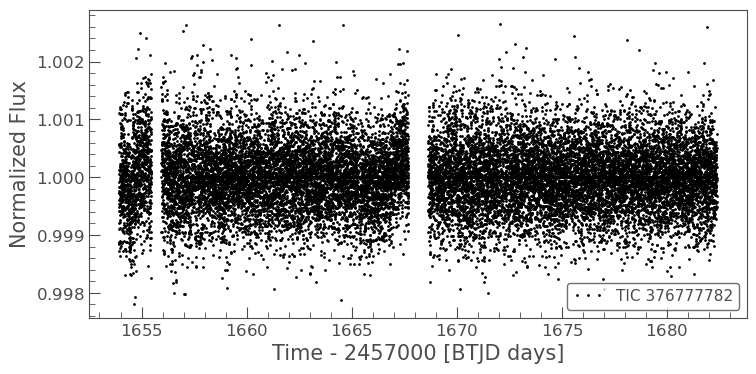

In [32]:
tess = tess.flatten(window_length = 1790).remove_outliers() 
## Esse e o passo anterior podem ser realizados na mesma linha de código.
tess.plot(linewidth = 0, marker = '.',  color = 'black') 


In [33]:
# Converte para DataFrame
df = tess.to_pandas()

# Seleciona apenas as colunas de interesse (tempo e fluxo)
# Nota: No Lightkurve v2+, o tempo é o índice do DataFrame
df_export = df[['flux']]

# Salva em CSV
df_export.to_csv("lc3.csv")

Aqui, estaremos fazendo um dos principais pontos desse `notebook`. Vamos utilizar a função `t0_periodogram` para construir um periodograma da curva de luz acima utilizando o algorimo BLS discutido na seção 3. Para quem não conhece, o periodograma se trata de um gráfico que mostra a intensidade de cada período presente no sinal. Limitamos também o período máximo exibido no gráfico para 20 dias para melhor observação. Adiantamos que o período orbital obtido é inferior a 20 dias, dessa forma tal limitação não influencia na análise dos dados. 

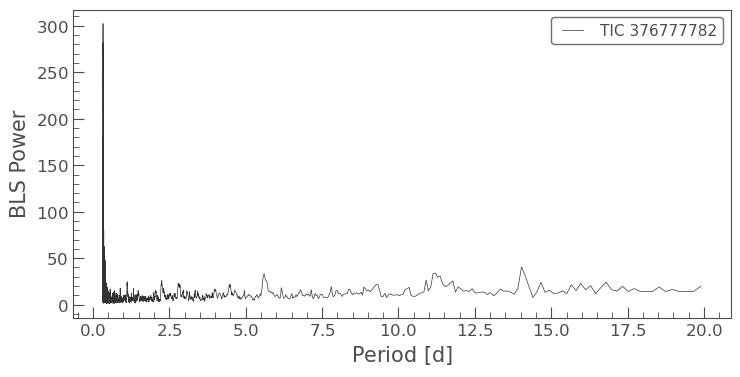

In [36]:
pg = tess.to_periodogram(method='bls', maximum_period=20)
pg.plot(view='period');

Com o periodograma montado, agora coletamos as informações que precisamos para a modelagem do nosso trânsito. Utilizamos os seguintes comandos para coletarmos dados de período, época e duração do trânsito no pico do nosso gráfico. Se o leitor bem se lembra, todos esses parâmetros são estimados pelo algoritmo para buscar o período que maximiza aa expressão (11). Agora estamos resgatando os dados que produzem o maior "ajuste" do modelo com a curva de luz. 

In [37]:
planet_period = pg.period_at_max_power

# Checando o valor do período:
planet_period

<Quantity 0.33159275 d>

In [17]:
f=1/planet_period;f

<Quantity 0.31345457 1 / d>

A fim de comprovar a eficiência do algoritmo, vamos comparar o resultado do período obtido com os dados disponíveis na literatura [1]. O valor do período encontrado no artigo da caracterização do planeta é de aproximadamente 4.4247110 dias. Ao calcularmos o desvio da nossa medida com a disponível na literatura, obtemos uma diferença de apenas $\Delta T \% = 1,7 \cdot 10^{-3} \%$.

Utilizando os parâmetros do trânsito obtidos anteriormente, dobramos a curva de luz, de modo a obter um gráfico mais simples de analisar e visualizar o trânsito. Para isso, usamos a função `fold` com os devidos argumentos.

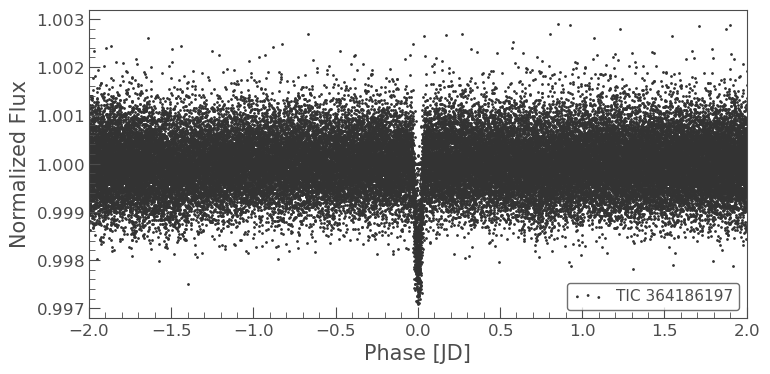

In [23]:
ax = tess.fold(period=planet_period, epoch_time=planet_b_t0).scatter()
ax.set_xlim(-2, 2);

Para finalizarmos, vamos modelar o trânsito do planeta, visualizando assim como o algoritmo prevê o formato do sinal e consegue aferir precisamente o período do nosso exoplaneta de interesse. Começamos criando uma variável para o modelo e inserimos novamente as características do período que mais se encaixa à curva de luz. Posteriormente, plotamos em um mesmo gráfico a curva de luz dobrada e o modelo, em vermelho.

(-2.0, 2.0)

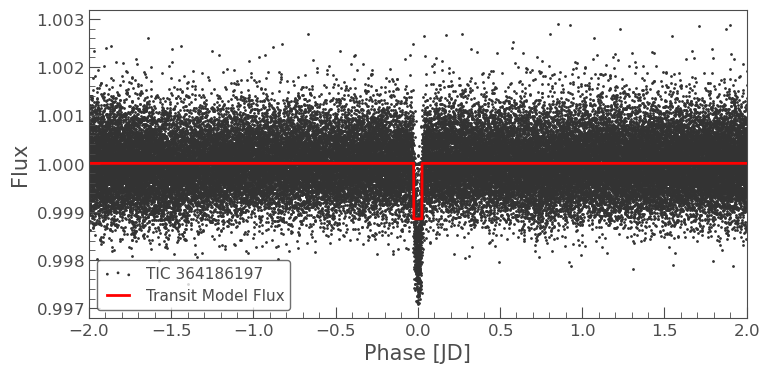

In [24]:
planet_b_model = pg.get_transit_model(period=planet_period,
                                       transit_time=planet_b_t0,
                                       duration=planet_b_dur)
ax = tess.fold(period=planet_period, epoch_time=planet_b_t0).scatter()
planet_b_model.fold(planet_period, planet_b_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-2, 2)

## Conclusão

Nesse projeto, abordamos conceitos essenciais para a astronomia e a exoplanetologia. Discutimos o conceito de trânsito planetário e como a interação (nesse caso, luminosa) entre a estrela e o planeta nos ajuda a identificar indiretamente novos exoplanetas. Apresentamos o conceito de fluxo luminoso, curva de luz e periodogramas, que são peças-chave para a exoplanetologia, além de mencionar como acontece o trabalho da missão TESS.

Em seguida, buscamos mostrar uma visão estatística de um algoritmo para a detecção de período orbital a partir do trânsito planetário. Após uma grande discussão sobre o método BLS, implementamos um código buscando detectar o período orbital do exoplaneta TOI-1408b.

Com o código feito, conseguimos modelar o trânsito do nosso planeta a partir de funções obtidas na biblioteca, de forma a comprovar as considerações feitas na análise estatística do BLS. Posteriormente, comparamos o nosso valor obtido com o artigo que caracterizou o mesmo exoplaneta. Obtivemos um erro relativo de apenas $1,7 \cdot 10^{-3} \%$. O pequeno desvio mostra que o método utilizado neste `Notebook` está coerente com os métodos empregados por outros pesquisadores.

Concluímos, em suma, que a implementação do método, em geral, foi um sucesso. Além de a biblioteca se mostrar simples de ser utilizada, conseguimos adquirir valores totalmente coerentes com os esperados. Por fim, percebemos que este `Notebook` se mostra proveitoso para a identificação e caracterização de exoplanetas de forma simples.

## Referências 

[1] Ge, J. and Zeng, L., 2023. Doppler confirmation of TESS planet candidate TOI-1408.01: Grazing transit and likely eccentric orbit. Astronomy & Astrophysics, 675, pp.A65. 

[2] Cassen, P., Guillot, T. and Quirrenbach, A. (eds.), 2006. Extrasolar Planets. University of Arizona Press, pp. 115-123.

[3] Léna, P. and Lebrun, F., 2012. Observational Astrophysics. 3rd ed. Springer, pp. 79-102.

[4] Lightkurve, 2023. Exoplanets: Identifying Transiting Planet Signals.

[5] Space Telescope Science Institute, 2018. TESS Instrument Handbook Version 0.1.

[6] Kovács, G., Zucker, S. and Mazeh, T., 2002. A box-fitting algorithm in the search for periodic transits. Astronomy & Astrophysics, 391 (3), pp. 369-375.

[7] Mayor, M. and Queloz, D., 1995. Nature 378, 355

[8] NASA Exoplent Archive, 2024.